In [15]:
import os
import re
import json
import pickle
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer, TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight

# =====================
# CONFIG
# =====================
SEED = 42

# Chọn 15 category có số lượng mẫu nhiều nhất
TOP_K = 15

# None = dùng toàn bộ dữ liệu trong mỗi category
# Có thể đặt ví dụ 5000 nếu muốn cân bằng / train nhanh hơn
MAX_SAMPLES_PER_CLASS = None

# TF-IDF config cho pipeline học máy
MAX_FEATURES = 50000
NGRAM_RANGE = (1, 2)
MIN_DF = 2
MAX_DF = 0.95

# =====================
# Đường dẫn Kaggle
# =====================
INPUT_PATH = "/kaggle/input/datasets/rmisra/news-category-dataset/News_Category_Dataset_v3.json"

OUTPUT_DIR = Path("/kaggle/working")
FEATURE_DIR = OUTPUT_DIR / "features_ml"
MODEL_DIR = OUTPUT_DIR / "models_ml"
RESULT_DIR = OUTPUT_DIR / "results_ml"

FEATURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# =====================
# Reproducibility
# =====================
random.seed(SEED)
np.random.seed(SEED)

print("Input path:", INPUT_PATH)
print("Output dir:", OUTPUT_DIR)


Input path: /kaggle/input/datasets/rmisra/news-category-dataset/News_Category_Dataset_v3.json
Output dir: /kaggle/working


In [16]:
df = pd.read_json(INPUT_PATH, lines=True)

print("Shape:", df.shape)
display(df.head())
print("Columns:", df.columns.tolist())


Shape: (209527, 6)


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


Columns: ['link', 'headline', 'category', 'short_description', 'authors', 'date']


In [17]:
df = df[["category", "headline", "short_description"]].copy()

df["headline"] = df["headline"].fillna("")
df["short_description"] = df["short_description"].fillna("")
df["text"] = df["headline"] + " " + df["short_description"]

print("Shape after text processing:", df.shape)
display(df[["category", "headline", "short_description", "text"]].head())


Shape after text processing: (209527, 4)


,category,headline,short_description,text
0,U.S. NEWS,Over 4 Million Americans Roll Up Sleeves For O...,Health experts said it is too early to predict...,Over 4 Million Americans Roll Up Sleeves For O...
1,U.S. NEWS,"American Airlines Flyer Charged, Banned For Li...",He was subdued by passengers and crew when he ...,"American Airlines Flyer Charged, Banned For Li..."
2,COMEDY,23 Of The Funniest Tweets About Cats And Dogs ...,"""Until you have a dog you don't understand wha...",23 Of The Funniest Tweets About Cats And Dogs ...
3,PARENTING,The Funniest Tweets From Parents This Week (Se...,"""Accidentally put grown-up toothpaste on my to...",The Funniest Tweets From Parents This Week (Se...
4,U.S. NEWS,Woman Who Called Cops On Black Bird-Watcher Lo...,Amy Cooper accused investment firm Franklin Te...,Woman Who Called Cops On Black Bird-Watcher Lo...


In [18]:
print("===== DATA OVERVIEW =====")
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicated rows:", df.duplicated().sum())
print("Duplicated text:", df["text"].duplicated().sum())

print("\nNumber of categories:", df["category"].nunique())

category_counts = df["category"].value_counts()
category_percent = df["category"].value_counts(normalize=True) * 100

label_dist = pd.DataFrame({
    "count": category_counts,
    "percent": category_percent
})

print("\nTop 20 categories:")
display(label_dist.head(20))

print("\nBottom 20 categories:")
display(label_dist.tail(20))

label_dist.to_csv(RESULT_DIR / "eda_category_distribution.csv")


===== DATA OVERVIEW =====
Shape: (209527, 4)

Missing values:
category             0
headline             0
short_description    0
text                 0
dtype: int64

Duplicated rows: 471
Duplicated text: 489

Number of categories: 42

Top 20 categories:


,count,percent
category,,
POLITICS,35602,16.991605
WELLNESS,17945,8.564529
ENTERTAINMENT,17362,8.286283
TRAVEL,9900,4.724928
STYLE & BEAUTY,9814,4.683883
PARENTING,8791,4.195641
HEALTHY LIVING,6694,3.194815
QUEER VOICES,6347,3.029204
FOOD & DRINK,6340,3.025863



Bottom 20 categories:


,count,percent
category,,
MEDIA,2944,1.405070
WEIRD NEWS,2777,1.325366
GREEN,2622,1.251390
WORLDPOST,2579,1.230868
RELIGION,2577,1.229913
STYLE,2254,1.075756
SCIENCE,2206,1.052848
TECH,2104,1.004167
TASTE,2096,1.000348


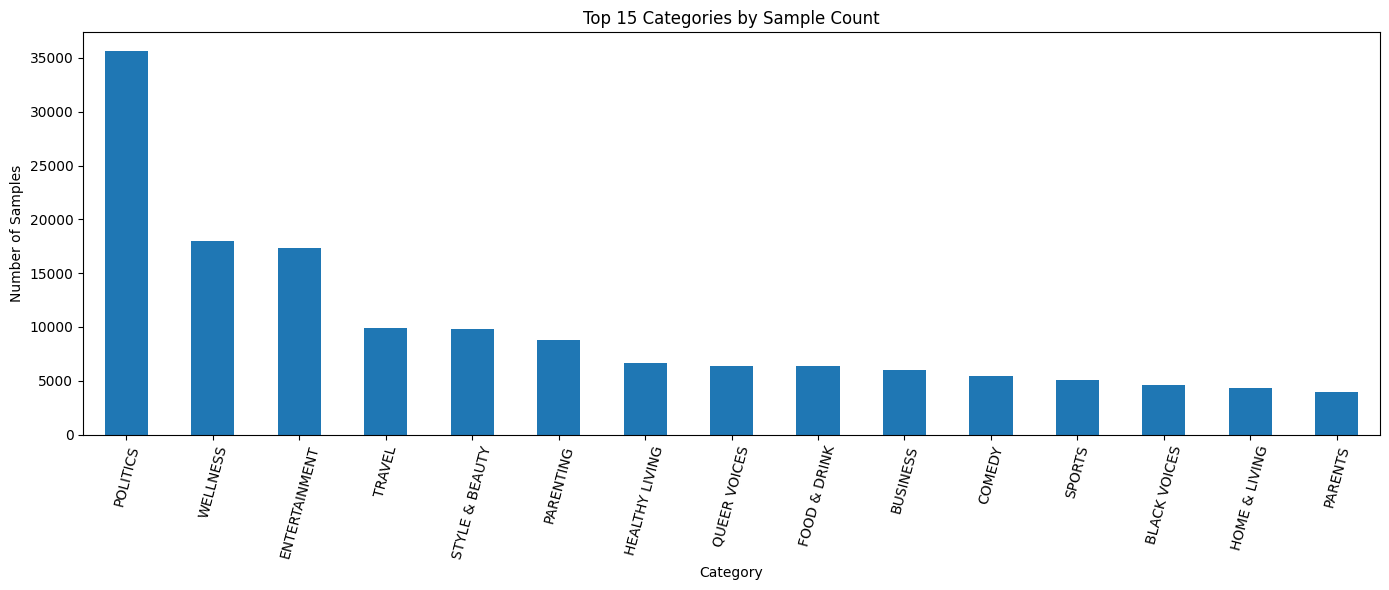

===== CLASS IMBALANCE =====
Largest class: POLITICS 35602
Smallest class: EDUCATION 1014
Imbalance ratio: 35.11


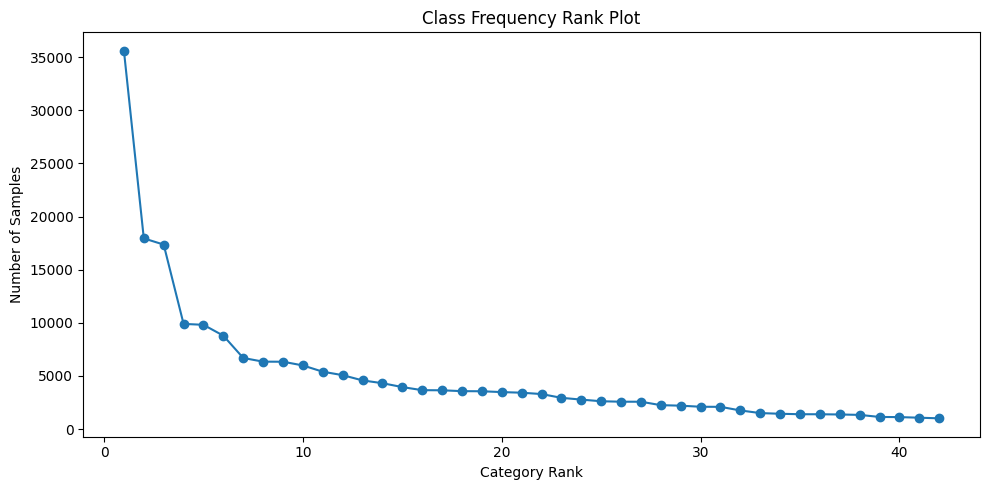

In [19]:
plt.figure(figsize=(14, 6))
category_counts.head(TOP_K).plot(kind="bar")
plt.title(f"Top {TOP_K} Categories by Sample Count")
plt.xlabel("Category")
plt.ylabel("Number of Samples")
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig(RESULT_DIR / f"eda_top{TOP_K}_category_distribution.png", dpi=150)
plt.show()

max_count = category_counts.max()
min_count = category_counts.min()
imbalance_ratio = max_count / min_count

print("===== CLASS IMBALANCE =====")
print("Largest class:", category_counts.idxmax(), max_count)
print("Smallest class:", category_counts.idxmin(), min_count)
print("Imbalance ratio:", round(imbalance_ratio, 2))

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(category_counts) + 1), category_counts.values, marker="o")
plt.title("Class Frequency Rank Plot")
plt.xlabel("Category Rank")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.savefig(RESULT_DIR / "eda_class_rank_plot.png", dpi=150)
plt.show()


,headline_word_count,description_word_count,text_word_count,headline_char_count,description_char_count,text_char_count
count,209527.000000,209527.000000,209527.000000,209527.000000,209527.000000,209527.000000
mean,9.600744,19.669026,29.269770,58.415355,114.208670,173.624025
std,3.068507,14.152783,13.803927,18.808506,80.840575,78.552970
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,8.000000,10.000000,20.000000,46.000000,59.000000,123.000000
50%,10.000000,19.000000,28.000000,60.000000,120.000000,171.000000
75%,12.000000,24.000000,35.000000,71.000000,134.000000,208.000000
max,44.000000,243.000000,245.000000,320.000000,1472.000000,1487.000000


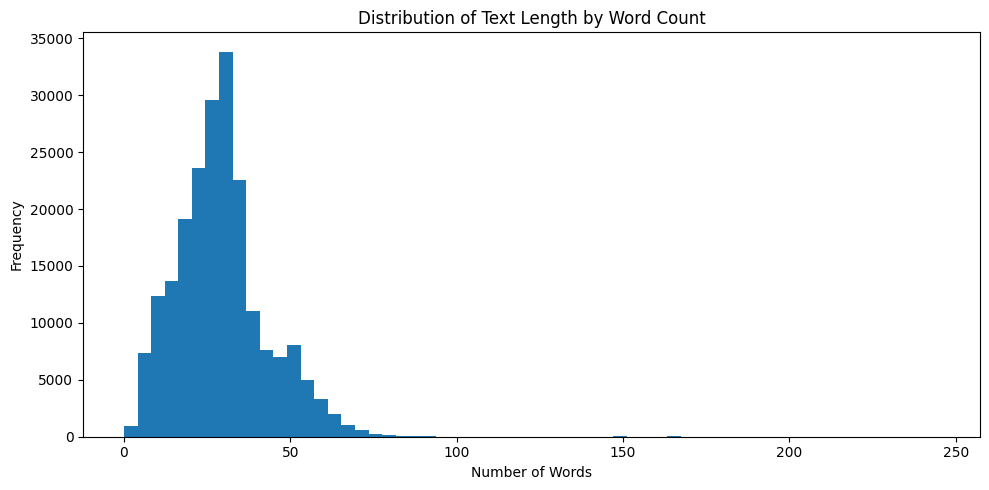

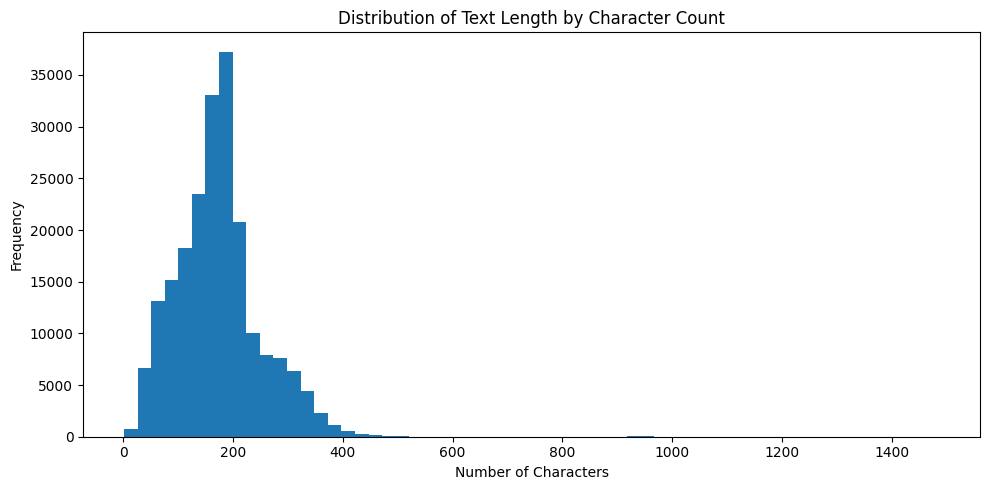

In [20]:
df["headline_word_count"] = df["headline"].apply(lambda x: len(str(x).split()))
df["description_word_count"] = df["short_description"].apply(lambda x: len(str(x).split()))
df["text_word_count"] = df["text"].apply(lambda x: len(str(x).split()))

df["headline_char_count"] = df["headline"].apply(len)
df["description_char_count"] = df["short_description"].apply(len)
df["text_char_count"] = df["text"].apply(len)

length_stats = df[
    [
        "headline_word_count",
        "description_word_count",
        "text_word_count",
        "headline_char_count",
        "description_char_count",
        "text_char_count"
    ]
].describe()

display(length_stats)
length_stats.to_csv(RESULT_DIR / "eda_length_statistics.csv")

plt.figure(figsize=(10, 5))
plt.hist(df["text_word_count"], bins=60)
plt.title("Distribution of Text Length by Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(RESULT_DIR / "eda_text_word_count_distribution.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df["text_char_count"], bins=60)
plt.title("Distribution of Text Length by Character Count")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(RESULT_DIR / "eda_text_char_count_distribution.png", dpi=150)
plt.show()


,count,mean,median,std,min,max
category,,,,,,
POLITICS,35602,26.267176,25.0,12.947379,0,245
WELLNESS,17945,39.036556,36.0,11.747990,3,171
ENTERTAINMENT,17362,23.200380,21.0,11.482405,1,98
TRAVEL,9900,34.757475,33.0,13.257635,1,175
STYLE & BEAUTY,9814,32.168229,32.0,8.167557,2,165
PARENTING,8791,38.456148,35.0,11.371665,5,150
HEALTHY LIVING,6694,28.302062,25.0,17.563082,1,176
QUEER VOICES,6347,29.784780,27.0,14.643220,0,85
FOOD & DRINK,6340,26.179495,25.0,10.631516,4,133


/tmp/ipykernel_57/995170755.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=top_categories_for_length, showfliers=False)


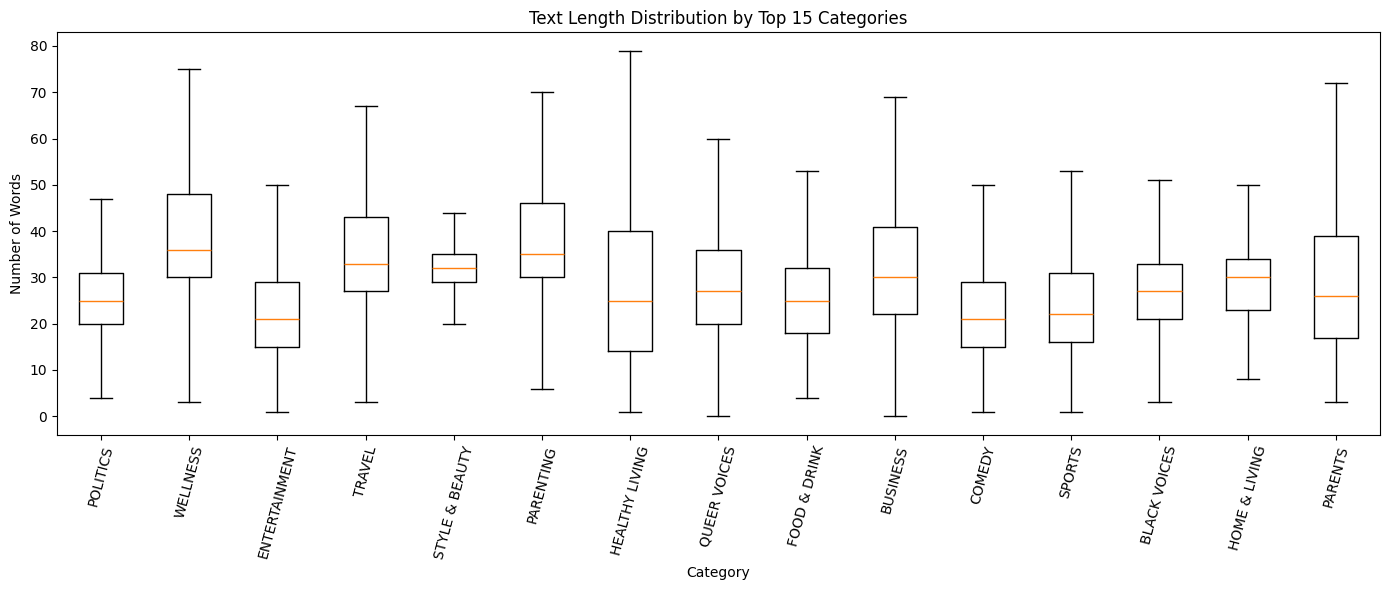

In [21]:
length_by_category = (
    df.groupby("category")["text_word_count"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("count", ascending=False)
)

display(length_by_category.head(20))
length_by_category.to_csv(RESULT_DIR / "eda_length_by_category.csv")

top_categories_for_length = category_counts.head(TOP_K).index
df_top_for_length = df[df["category"].isin(top_categories_for_length)]

plt.figure(figsize=(14, 6))
data_to_plot = [
    df_top_for_length[df_top_for_length["category"] == cat]["text_word_count"]
    for cat in top_categories_for_length
]

plt.boxplot(data_to_plot, labels=top_categories_for_length, showfliers=False)
plt.title(f"Text Length Distribution by Top {TOP_K} Categories")
plt.xlabel("Category")
plt.ylabel("Number of Words")
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig(RESULT_DIR / "eda_text_length_by_category_boxplot.png", dpi=150)
plt.show()


Vocabulary size: 107075
Total words after cleaning: 3408187
Top 30 words:
[('new', 19649), ('trump', 16506), ("it's", 13088), ('people', 12471), ('time', 12403), ('just', 12344), ('like', 11913), ('photos', 11424), ('day', 11199), ('year', 9628), ('life', 9481), ('make', 9218), ('said', 8057), ('world', 7902), ('know', 7679), ('video', 7514), ('best', 7496), ('says', 6997), ('want', 6975), ("don't", 6943), ('donald', 6884), ('love', 6842), ('week', 6826), ('way', 6815), ('years', 6757), ('women', 6499), ('need', 6339), ('president', 5981), ('good', 5802), ('health', 5727)]


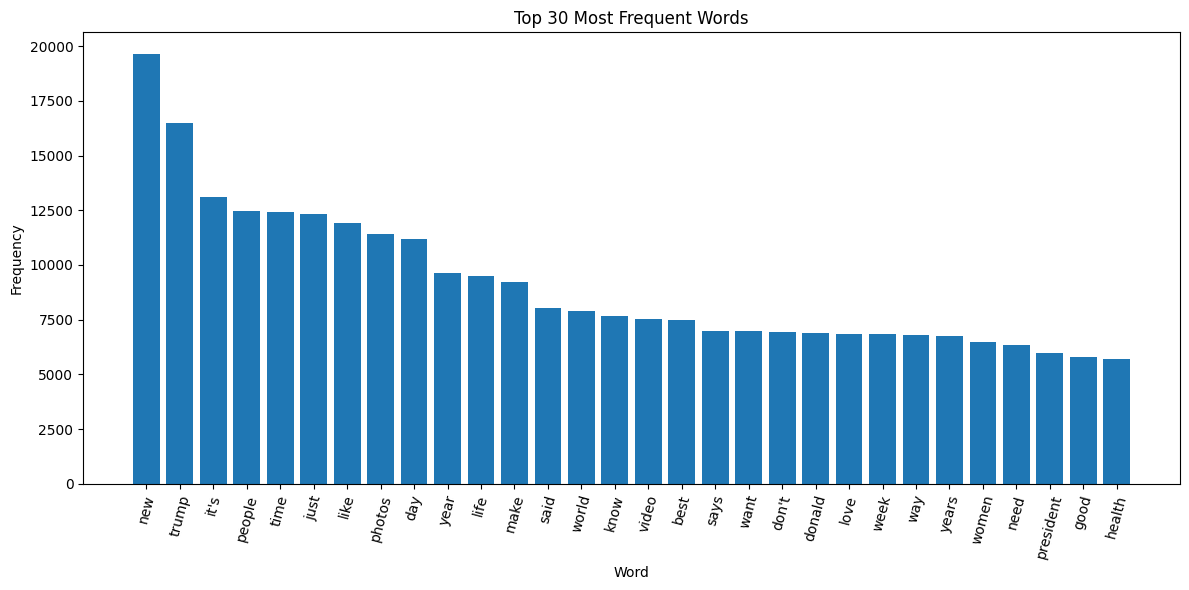

In [22]:
def eda_clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["eda_clean_text"] = df["text"].apply(eda_clean_text)

all_words = []

for text in df["eda_clean_text"]:
    words = text.split()
    words = [
        w for w in words
        if w not in ENGLISH_STOP_WORDS and len(w) > 2
    ]
    all_words.extend(words)

word_counts = Counter(all_words)

print("Vocabulary size:", len(word_counts))
print("Total words after cleaning:", len(all_words))
print("Top 30 words:")
print(word_counts.most_common(30))

top_words = word_counts.most_common(30)
top_words_df = pd.DataFrame(top_words, columns=["word", "count"])
top_words_df.to_csv(RESULT_DIR / "eda_top_words.csv", index=False)

words = [w for w, c in top_words]
counts = [c for w, c in top_words]

plt.figure(figsize=(12, 6))
plt.bar(words, counts)
plt.title("Top 30 Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig(RESULT_DIR / "eda_top30_words.png", dpi=150)
plt.show()


Top bigrams:


,bigram,count
0,donald trump,6666
1,new york,3291
2,year old,2902
3,hillary clinton,2029
4,white house,1790
5,health care,1279
6,supreme court,1222
7,climate change,1165
8,check huffpost,1040
9,new year,1038



Top trigrams:


,trigram,count
0,want sure check,747
1,new york city,741
2,twitter facebook tumblr,677
3,facebook tumblr pinterest,642
4,sure check huffpost,606
5,check huffpost style,597
6,huffpost style twitter,581
7,style twitter facebook,569
8,new york times,446
9,tumblr pinterest instagram,405


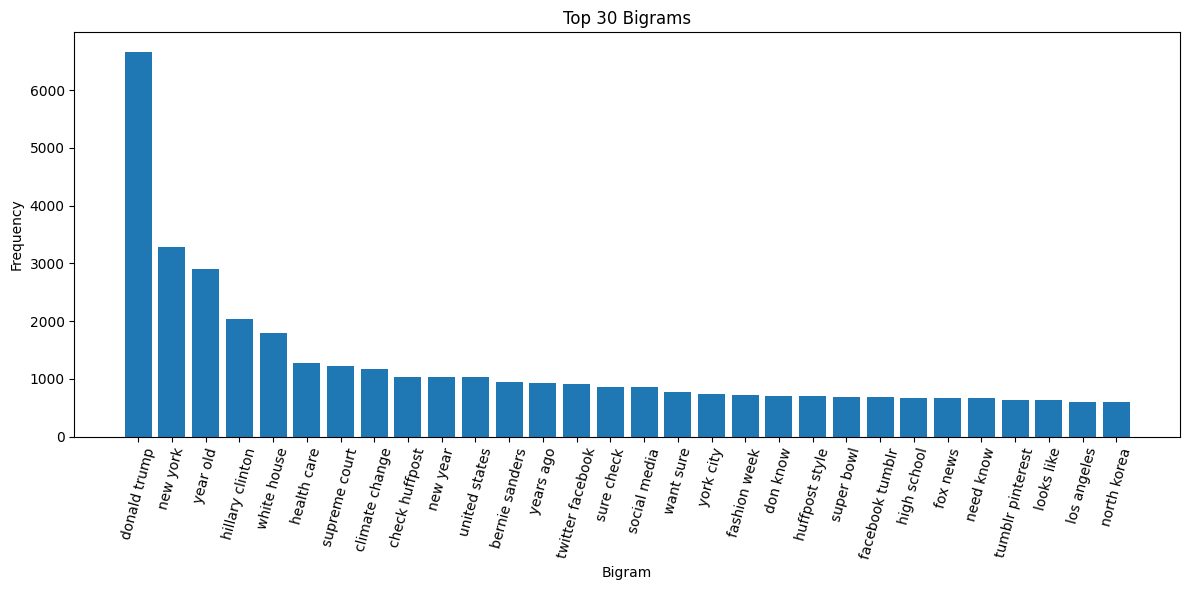

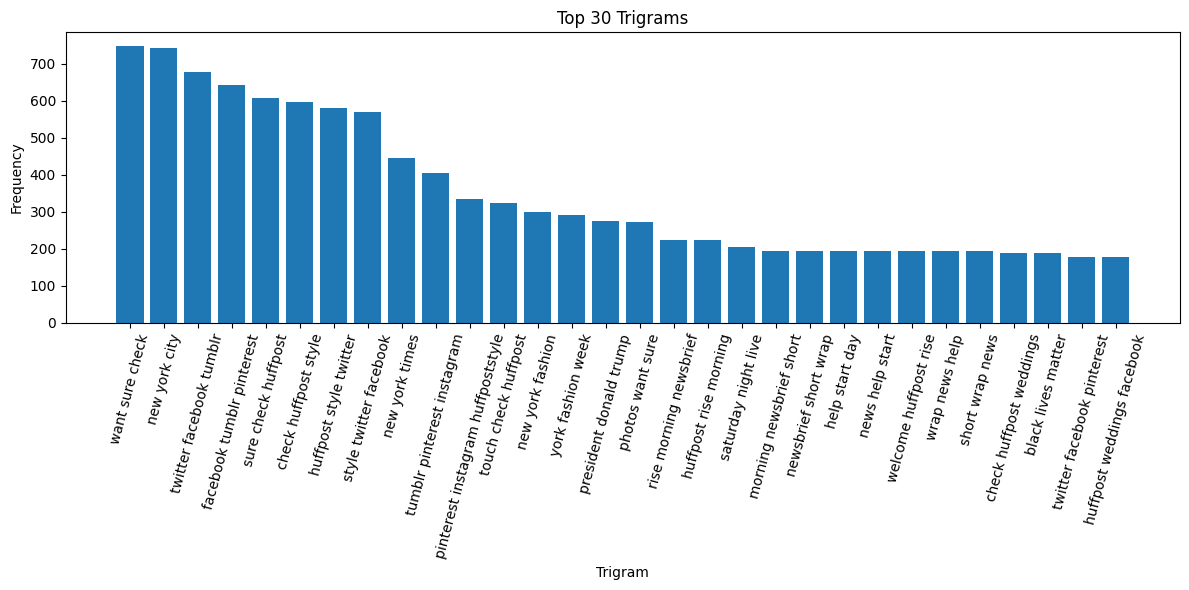

In [23]:
def get_top_ngrams(texts, ngram_range=(2, 2), top_n=30):
    vectorizer = CountVectorizer(
        stop_words="english",
        ngram_range=ngram_range,
        min_df=2
    )

    X_counts = vectorizer.fit_transform(texts)
    counts = np.asarray(X_counts.sum(axis=0)).ravel()
    vocab = np.array(vectorizer.get_feature_names_out())
    top_indices = counts.argsort()[::-1][:top_n]

    return list(zip(vocab[top_indices], counts[top_indices]))

top_bigrams = get_top_ngrams(df["eda_clean_text"], ngram_range=(2, 2), top_n=30)
top_trigrams = get_top_ngrams(df["eda_clean_text"], ngram_range=(3, 3), top_n=30)

pd.DataFrame(top_bigrams, columns=["bigram", "count"]).to_csv(
    RESULT_DIR / "eda_top_bigrams.csv",
    index=False
)

pd.DataFrame(top_trigrams, columns=["trigram", "count"]).to_csv(
    RESULT_DIR / "eda_top_trigrams.csv",
    index=False
)

print("Top bigrams:")
display(pd.DataFrame(top_bigrams, columns=["bigram", "count"]))

print("\nTop trigrams:")
display(pd.DataFrame(top_trigrams, columns=["trigram", "count"]))

bigrams, bigram_counts = zip(*top_bigrams)

plt.figure(figsize=(12, 6))
plt.bar(bigrams, bigram_counts)
plt.title("Top 30 Bigrams")
plt.xlabel("Bigram")
plt.ylabel("Frequency")
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig(RESULT_DIR / "eda_top30_bigrams.png", dpi=150)
plt.show()

trigrams, trigram_counts = zip(*top_trigrams)

plt.figure(figsize=(12, 6))
plt.bar(trigrams, trigram_counts)
plt.title("Top 30 Trigrams")
plt.xlabel("Trigram")
plt.ylabel("Frequency")
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig(RESULT_DIR / "eda_top30_trigrams.png", dpi=150)
plt.show()



Category: POLITICS
[('trump', np.int64(14592)), ('donald', np.int64(4660)), ('president', np.int64(3912)), ('new', np.int64(2826)), ('gop', np.int64(2807)), ('clinton', np.int64(2669)), ('said', np.int64(2633)), ('house', np.int64(2475)), ('obama', np.int64(2452)), ('says', np.int64(2388)), ('people', np.int64(2019)), ('state', np.int64(1925)), ('hillary', np.int64(1882)), ('white', np.int64(1838)), ('republican', np.int64(1644))]

Category: WELLNESS
[('life', np.int64(2763)), ('health', np.int64(2306)), ('people', np.int64(2059)), ('time', np.int64(1977)), ('new', np.int64(1804)), ('study', np.int64(1763)), ('day', np.int64(1445)), ('make', np.int64(1381)), ('like', np.int64(1372)), ('sleep', np.int64(1364)), ('cancer', np.int64(1322)), ('just', np.int64(1303)), ('don', np.int64(1146)), ('know', np.int64(1118)), ('love', np.int64(1113))]

Category: ENTERTAINMENT
[('new', np.int64(2064)), ('star', np.int64(1175)), ('trump', np.int64(1040)), ('just', np.int64(934)), ('film', np.int64(9

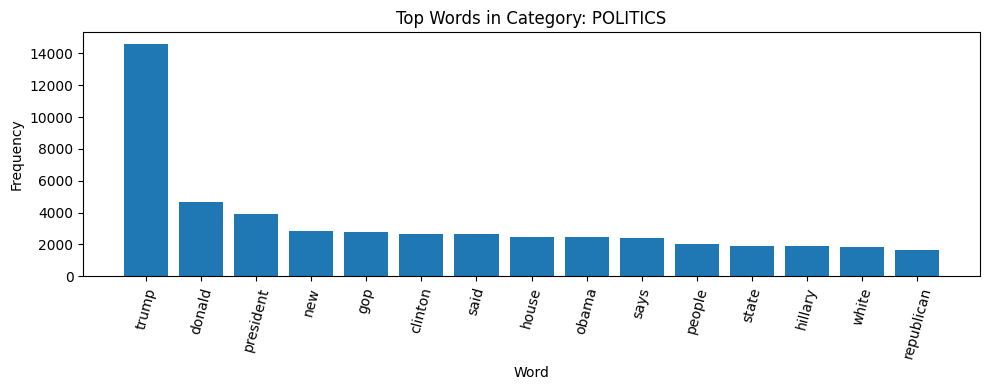

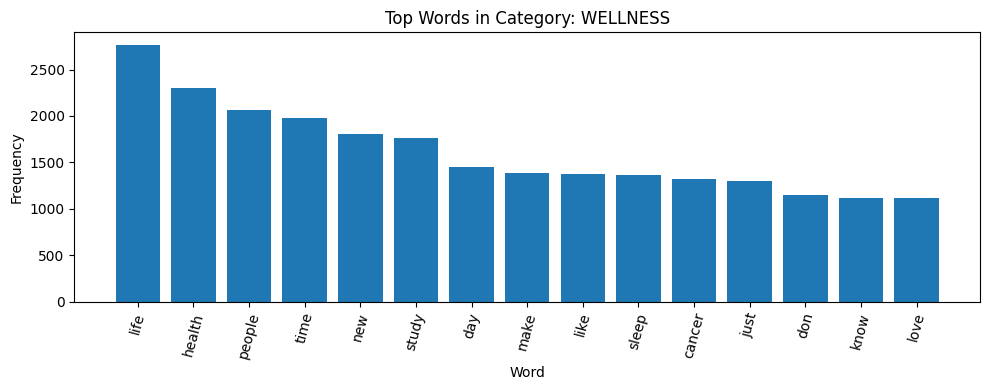

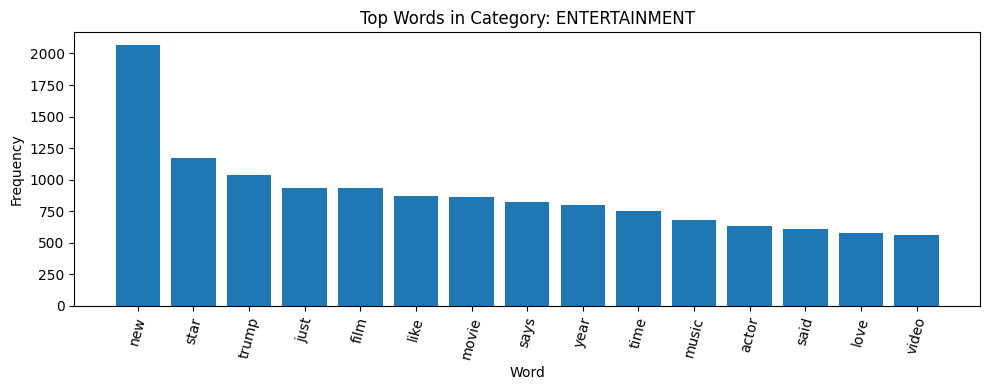

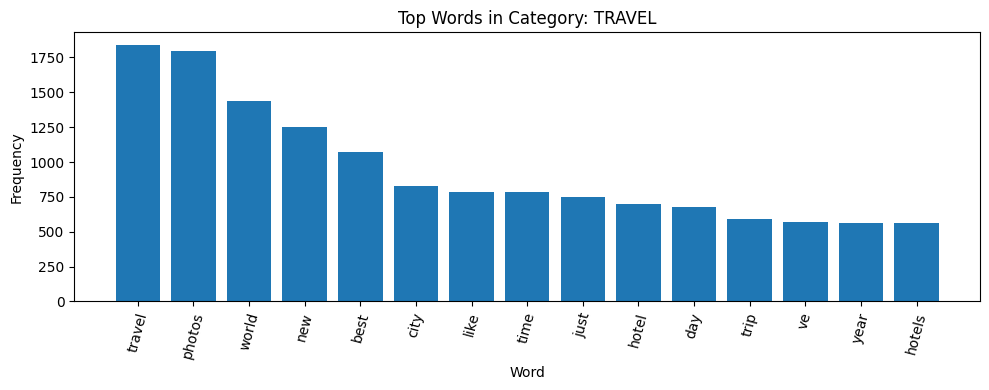

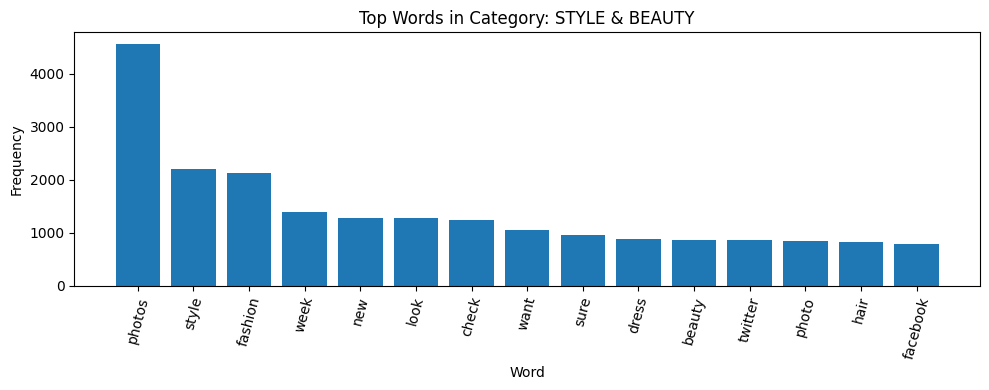

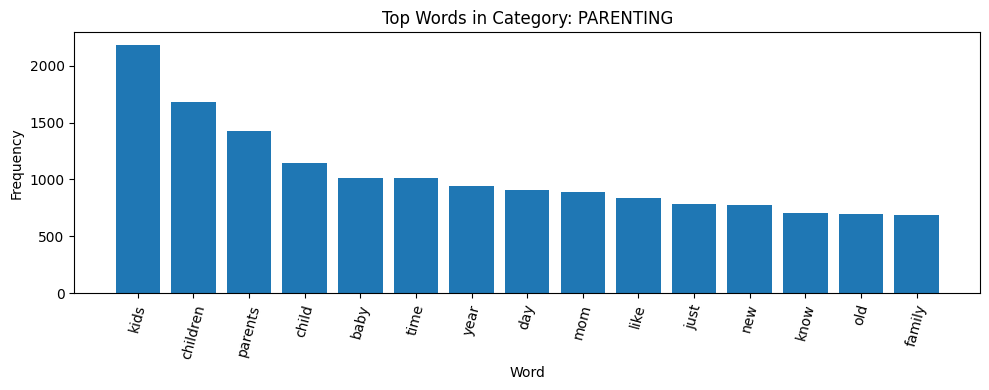

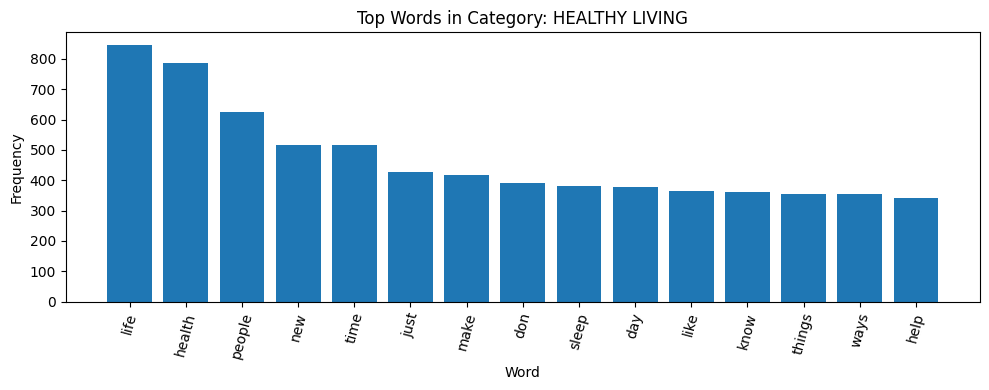

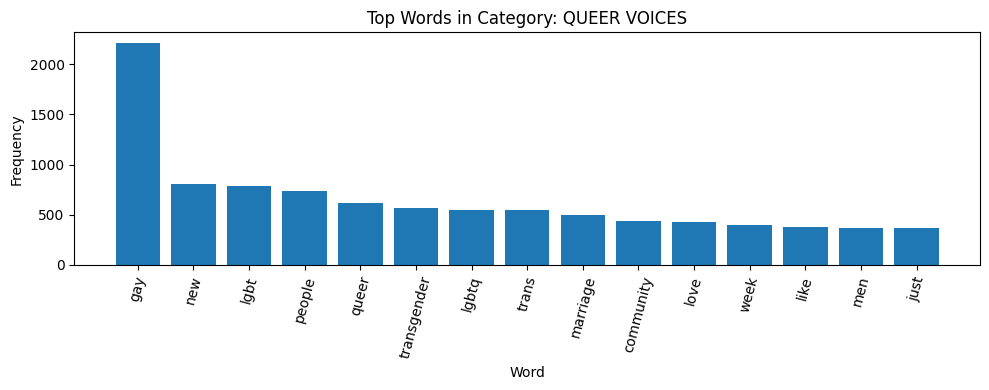

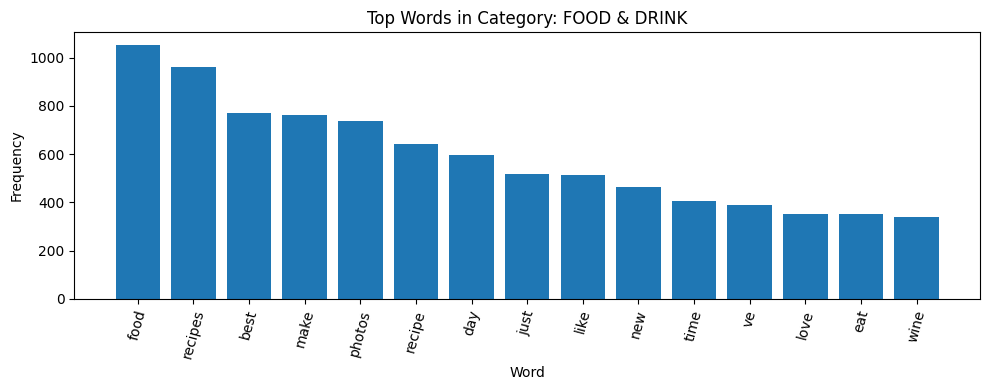

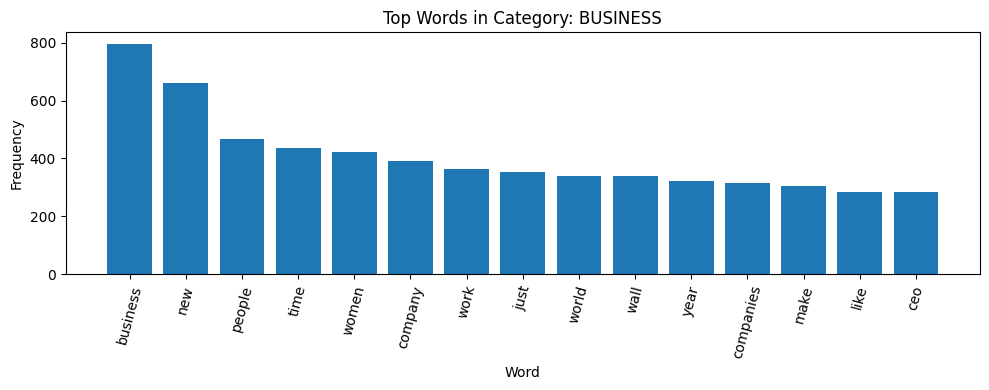

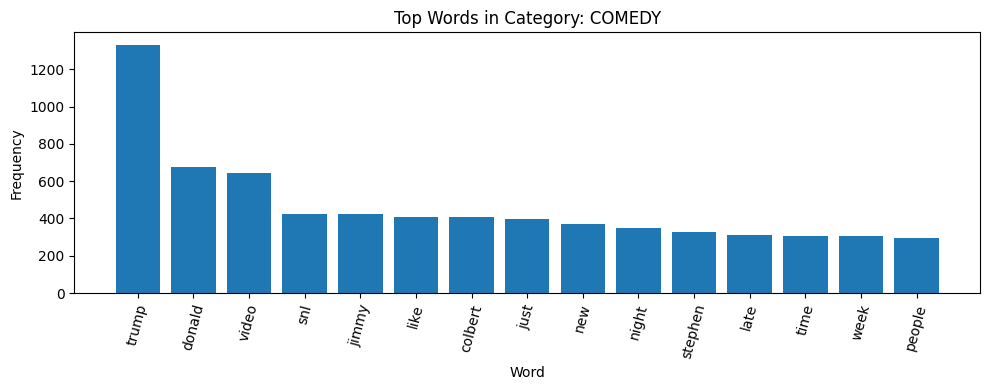

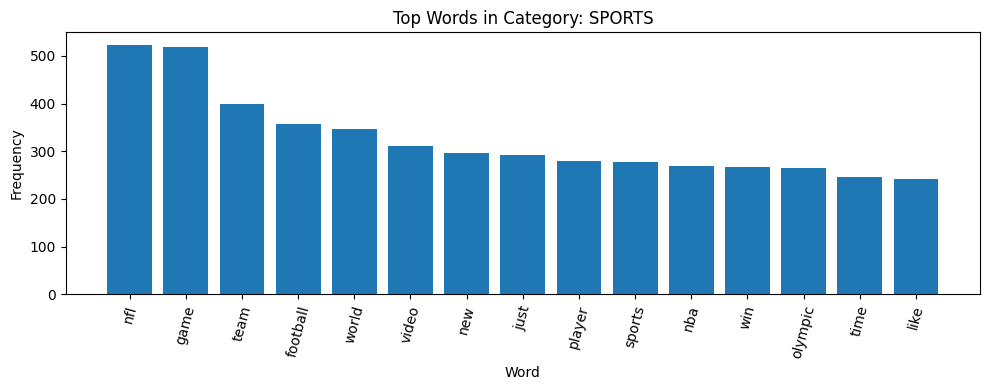

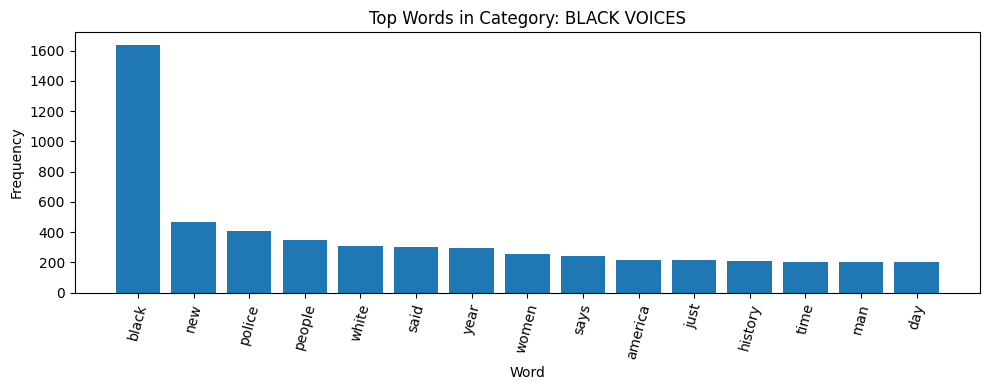

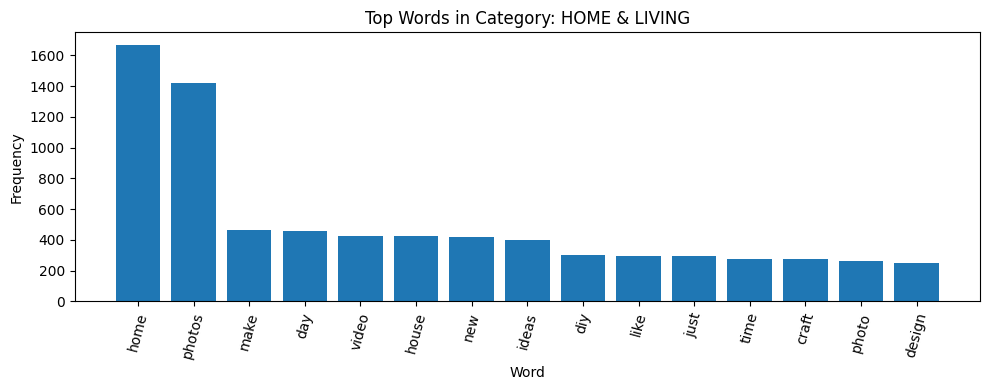

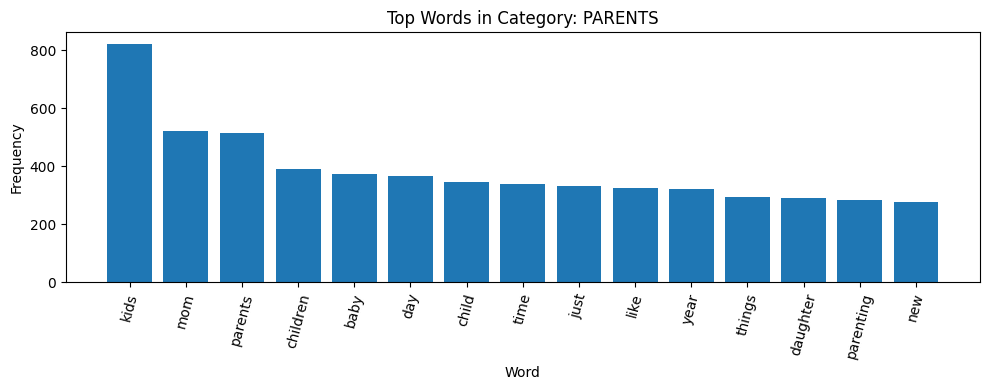

In [24]:
def top_words_by_category(dataframe, category, top_n=15):
    texts = dataframe[dataframe["category"] == category]["eda_clean_text"]

    vectorizer = CountVectorizer(
        stop_words="english",
        max_features=5000,
        min_df=2
    )

    X_counts = vectorizer.fit_transform(texts)
    counts = np.asarray(X_counts.sum(axis=0)).ravel()
    vocab = np.array(vectorizer.get_feature_names_out())
    top_indices = counts.argsort()[::-1][:top_n]

    return list(zip(vocab[top_indices], counts[top_indices]))


selected_categories = df["category"].value_counts().head(15).index.tolist()

category_keywords = {}

for cat in selected_categories:
    category_keywords[cat] = top_words_by_category(df, cat, top_n=15)

for cat, words_counts in category_keywords.items():
    print("\nCategory:", cat)
    print(words_counts)

# Lưu keywords ra file JSON
with open(RESULT_DIR / "eda_top_words_by_category.json", "w", encoding="utf-8") as f:
    json.dump(
        {cat: [(w, int(c)) for w, c in values] for cat, values in category_keywords.items()},
        f,
        ensure_ascii=False,
        indent=2
    )

# Vẽ top words cho 15 category đầu
for cat in selected_categories[:15]:
    words_counts = category_keywords[cat]
    words = [w for w, c in words_counts]
    counts = [c for w, c in words_counts]

    plt.figure(figsize=(10, 4))
    plt.bar(words, counts)
    plt.title(f"Top Words in Category: {cat}")
    plt.xlabel("Word")
    plt.ylabel("Frequency")
    plt.xticks(rotation=75)
    plt.tight_layout()

    safe_cat = re.sub(r"[^a-zA-Z0-9_]+", "_", cat.lower())
    plt.savefig(RESULT_DIR / f"eda_top_words_{safe_cat}.png", dpi=150)
    plt.show()

In [25]:
def top_tfidf_words_by_category(dataframe, category, top_n=15):
    category_df = dataframe[dataframe["category"] == category]

    vectorizer = TfidfVectorizer(
        stop_words="english",
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2
    )

    X_tfidf = vectorizer.fit_transform(category_df["eda_clean_text"])
    mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()
    vocab = np.array(vectorizer.get_feature_names_out())
    top_indices = mean_tfidf.argsort()[::-1][:top_n]

    return list(zip(vocab[top_indices], mean_tfidf[top_indices]))

selected_categories_for_eda = df["category"].value_counts().head(TOP_K).index.tolist()

tfidf_keywords = {}

for cat in selected_categories_for_eda:
    tfidf_keywords[cat] = top_tfidf_words_by_category(df, cat, top_n=15)

for cat, words_scores in tfidf_keywords.items():
    print("\nCategory:", cat)
    for word, score in words_scores:
        print(f"{word}: {score:.4f}")

with open(RESULT_DIR / "eda_tfidf_keywords_by_category.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            cat: [(w, float(s)) for w, s in values]
            for cat, values in tfidf_keywords.items()
        },
        f,
        ensure_ascii=False,
        indent=2
    )



Category: POLITICS
trump: 0.0325
donald: 0.0157
donald trump: 0.0154
president: 0.0130
clinton: 0.0111
gop: 0.0108
obama: 0.0106
new: 0.0102
house: 0.0095
said: 0.0092
says: 0.0091
hillary: 0.0085
people: 0.0080
state: 0.0077
white: 0.0076

Category: WELLNESS
life: 0.0157
health: 0.0134
people: 0.0125
time: 0.0121
study: 0.0114
new: 0.0110
sleep: 0.0101
day: 0.0096
cancer: 0.0093
make: 0.0092
like: 0.0092
just: 0.0087
love: 0.0083
know: 0.0082
don: 0.0080

Category: ENTERTAINMENT
new: 0.0142
star: 0.0094
trump: 0.0092
just: 0.0080
like: 0.0076
says: 0.0073
movie: 0.0073
film: 0.0070
year: 0.0069
time: 0.0067
music: 0.0059
season: 0.0057
actor: 0.0057
love: 0.0056
watch: 0.0055

Category: TRAVEL
travel: 0.0188
photos: 0.0172
world: 0.0155
new: 0.0134
best: 0.0122
city: 0.0099
like: 0.0097
time: 0.0095
just: 0.0092
hotel: 0.0092
day: 0.0086
trip: 0.0080
hotels: 0.0079
vacation: 0.0078
year: 0.0074

Category: STYLE & BEAUTY
photos: 0.0279
style: 0.0199
fashion: 0.0192
week: 0.0143
check:

Selected top categories:
['POLITICS', 'WELLNESS', 'ENTERTAINMENT', 'TRAVEL', 'STYLE & BEAUTY', 'PARENTING', 'HEALTHY LIVING', 'QUEER VOICES', 'FOOD & DRINK', 'BUSINESS', 'COMEDY', 'SPORTS', 'BLACK VOICES', 'HOME & LIVING', 'PARENTS']

Shape after selecting top categories: (148122, 11)
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
Name: count, dtype: int64


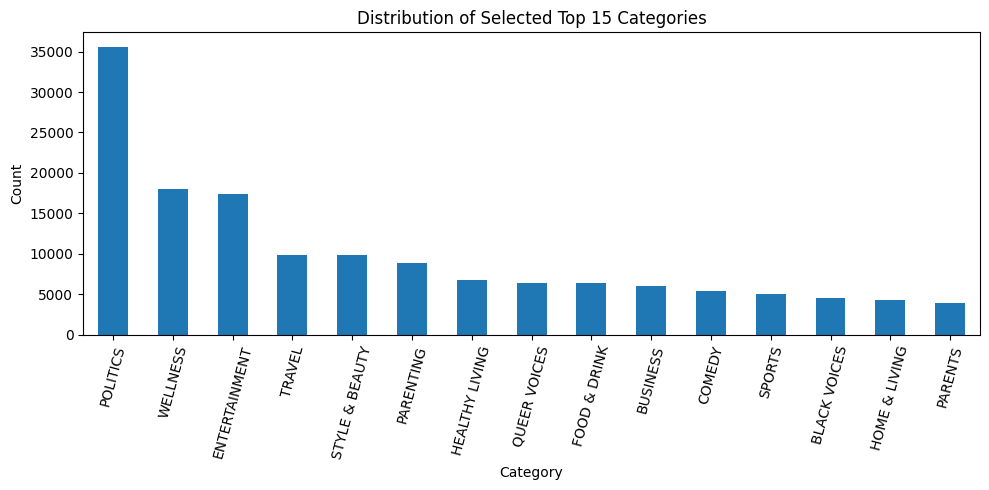

In [26]:
top_categories = df["category"].value_counts().head(TOP_K).index.tolist()
df_top = df[df["category"].isin(top_categories)].copy()

if MAX_SAMPLES_PER_CLASS is not None:
    df_top = (
        df_top.groupby("category", group_keys=False)
        .apply(lambda x: x.sample(
            n=min(len(x), MAX_SAMPLES_PER_CLASS),
            random_state=SEED
        ))
        .reset_index(drop=True)
    )

print("Selected top categories:")
print(top_categories)

print("\nShape after selecting top categories:", df_top.shape)
print(df_top["category"].value_counts())

plt.figure(figsize=(10, 5))
df_top["category"].value_counts().plot(kind="bar")
plt.title(f"Distribution of Selected Top {TOP_K} Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig(RESULT_DIR / f"eda_top{TOP_K}_category_distribution.png", dpi=150)
plt.show()

In [27]:
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_top["clean_text"] = df_top["text"].apply(clean_text)

display(df_top[["category", "text", "clean_text"]].head())

,category,text,clean_text
2,COMEDY,23 Of The Funniest Tweets About Cats And Dogs ...,23 of the funniest tweets about cats and dogs ...
3,PARENTING,The Funniest Tweets From Parents This Week (Se...,the funniest tweets from parents this week sep...
17,SPORTS,"Maury Wills, Base-Stealing Shortstop For Dodge...",maury wills base stealing shortstop for dodger...
20,ENTERTAINMENT,Golden Globes Returning To NBC In January Afte...,golden globes returning to nbc in january afte...
21,POLITICS,Biden Says U.S. Forces Would Defend Taiwan If ...,biden says u s forces would defend taiwan if c...


Tiền xử lí cho IF_IDF

In [33]:
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
def get_wordnet_pos(tag):
    if tag.startswith("J"):
        return wordnet.ADJ      # adjective
    elif tag.startswith("V"):
        return wordnet.VERB     # verb
    elif tag.startswith("N"):
        return wordnet.NOUN     # noun
    elif tag.startswith("R"):
        return wordnet.ADV      # adverb
    else:
        return wordnet.NOUN
def remove_stopwords_and_lemmatize(text):
    tokens = text.split()

    # Gán loại từ cho từng token
    tagged_tokens = pos_tag(tokens)

    processed_tokens = []

    for word, tag in tagged_tokens:
        if word not in stop_words:
            wordnet_pos = get_wordnet_pos(tag)
            lemma = lemmatizer.lemmatize(word, pos=wordnet_pos)
            processed_tokens.append(lemma)

    return " ".join(processed_tokens)

df_top["ml_clean_text"] = df_top["clean_text"].apply(remove_stopwords_and_lemmatize)

display(df_top[["category", "text", "clean_text", "ml_clean_text"]].head())

,category,text,clean_text,ml_clean_text
2,COMEDY,23 Of The Funniest Tweets About Cats And Dogs ...,23 of the funniest tweets about cats and dogs ...,23 funny tweet cat dog week sept 17 23 dog und...
3,PARENTING,The Funniest Tweets From Parents This Week (Se...,the funniest tweets from parents this week sep...,funny tweet parent week sept 17 23 accidentall...
17,SPORTS,"Maury Wills, Base-Stealing Shortstop For Dodge...",maury wills base stealing shortstop for dodger...,maury will base steal shortstop dodger dy 89 m...
20,ENTERTAINMENT,Golden Globes Returning To NBC In January Afte...,golden globes returning to nbc in january afte...,golden globe return nbc january year air past ...
21,POLITICS,Biden Says U.S. Forces Would Defend Taiwan If ...,biden says u s forces would defend taiwan if c...,biden say u force would defend taiwan china in...


'play'

In [34]:
from sklearn.model_selection import train_test_split

# Chia dữ liệu thành train, validation, test theo tỉ lệ 70/15/15
train_df, temp_df = train_test_split(
    df_top,
    test_size=0.30,
    random_state=42,
    stratify=df_top["category"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["category"]
)

print("Train size:", train_df.shape)
print("Validation size:", val_df.shape)
print("Test size:", test_df.shape)

Train size: (103685, 13)
Validation size: (22218, 13)
Test size: (22219, 13)


In [35]:
# Chỉ giữ 2 cột: nhãn và văn bản đã tiền xử lí
train_save = train_df[["category", "ml_clean_text"]].copy()
val_save = val_df[["category", "ml_clean_text"]].copy()
test_save = test_df[["category", "ml_clean_text"]].copy()

# Lưu thành 3 file CSV
train_save.to_csv(RESULT_DIR / "train_ml_clean_text.csv", index=False, encoding="utf-8")
val_save.to_csv(RESULT_DIR / "val_ml_clean_text.csv", index=False, encoding="utf-8")
test_save.to_csv(RESULT_DIR / "test_ml_clean_text.csv", index=False, encoding="utf-8")

print("Saved train file:", RESULT_DIR / "train_ml_clean_text.csv")
print("Saved validation file:", RESULT_DIR / "val_ml_clean_text.csv")
print("Saved test file:", RESULT_DIR / "test_ml_clean_text.csv")

Saved train file: /kaggle/working/results_ml/train_ml_clean_text.csv
Saved validation file: /kaggle/working/results_ml/val_ml_clean_text.csv
Saved test file: /kaggle/working/results_ml/test_ml_clean_text.csv
